# Substrate–Inhibitor Analysis

In this notebook, we study a substrate–inhibitor reaction–diffusion system from the perspective of diffusion-driven instability.

The aim is to understand when a homogeneous steady state becomes unstable after diffusion is introduced, leading to the formation of Turing patterns. Compared with the Schnakenberg model, this system contains a saturating inhibition term, making the steady state and instability regions more sensitive to parameter choice.

In particular, we:
- visualise the parameter regions where Turing instability can occur,
- compute the homogeneous steady state numerically,
- examine the nullclines and fixed point,
- analyse the Jacobian and eigenvalues,
- study the dispersion relation as a function of spatial wavenumber,
- and identify the unstable band of modes.

As before, we begin with the parameter-space picture before focusing on a representative parameter choice.

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import fsolve

from src.analysis_tools.derivatives import substrate_inhibitor_derivatives
from src.analysis_tools.turing import (
    compute_turing_mask,
    trace_det,
    turing_conditions,
    critical_diffusion_ratio,
    h_k2,
    dominant_lambda_k2,
    unstable_k2_band,
)
from src.analysis_tools.steady_states import (
    substrate_h,
    substrate_f,
    substrate_g,
    substrate_steady_state,
)

from src.visualiser import plot_phase_plane, plot_turing_relation

## 1. Parameter-space exploration

Before fixing a particular choice of parameters, we first examine where Turing instability is possible in the \((a,b)\)-parameter space.

For the substrate–inhibitor model,

$$
f(u,v)=a-u-h(u,v), \qquad 
g(u,v)=\alpha(b-v)-h(u,v),
$$

where

$$
h(u,v)=\frac{\rho u v}{1+u+Ku^2}.
$$

Unlike the Schnakenberg system, the homogeneous steady state is not available in a simple closed form. For each point \((a,b)\), we compute the steady state numerically, evaluate the Jacobian, and check whether diffusion destabilises the otherwise stable homogeneous state.

The contours below show the boundary of the Turing-unstable region for different diffusion ratios $d$.

In [2]:
alpha = 1.5
rho = 13.0
K = 0.05
gamma = 2.0

def substrate_derivative_wrapper(a, b):
    u0, v0 = substrate_steady_state(a, b, alpha, rho, K, guess=(a, b))

    if np.isnan(u0) or np.isnan(v0):
        return np.nan, np.nan, np.nan, np.nan

    return substrate_inhibitor_derivatives(a, b, alpha, rho, K, u0, v0)

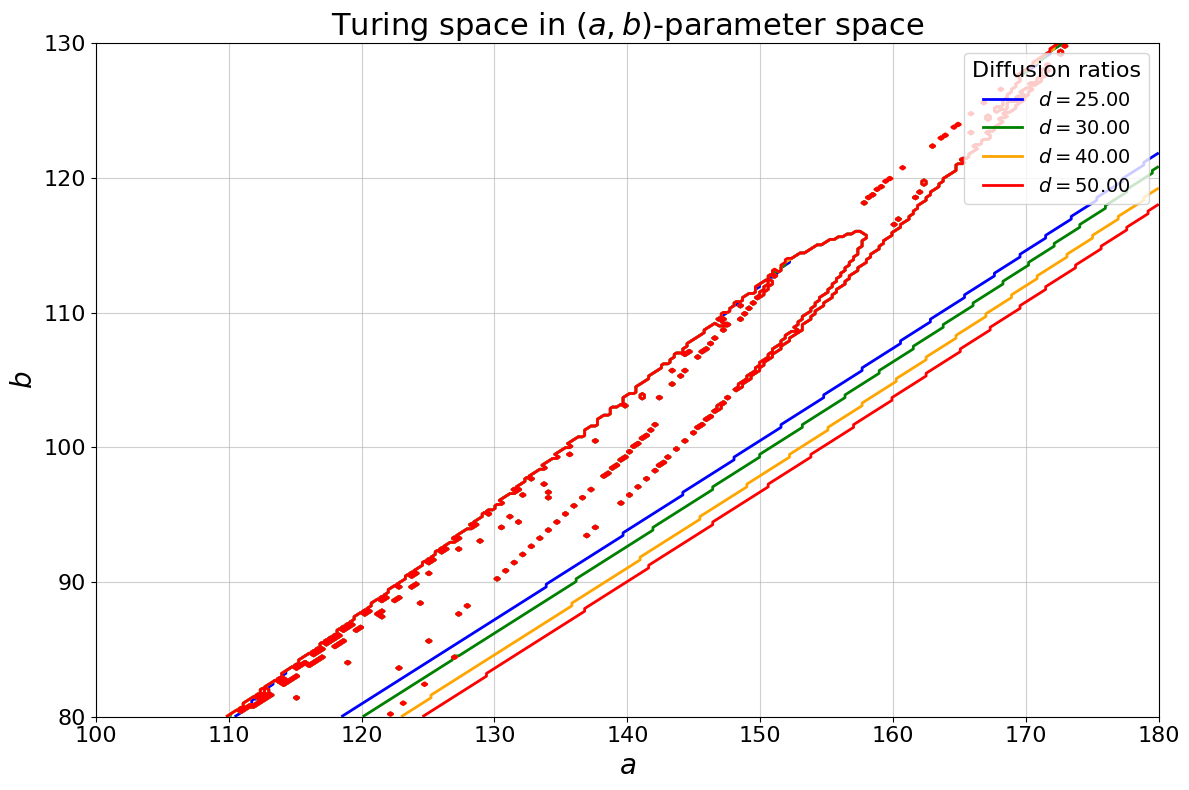

In [3]:
# Parameter grid
a_vals = np.linspace(100, 180, 250)
b_vals = np.linspace(80, 130, 250)
A, B = np.meshgrid(a_vals, b_vals)

# Diffusion ratios
d_values = [25, 30, 40, 50]
colors = ["blue", "green", "orange", "red"]

# Wavenumber range
k2_vals = np.linspace(0.01, 10, 100)

plt.figure(figsize=(12, 8))
legend_elements = []

for d_val, color in zip(d_values, colors):
    mask = compute_turing_mask(A, B, d_val, k2_vals, substrate_derivative_wrapper)

    plt.contour(A, B, mask, levels=[0.5], colors=color, linewidths=2)

    legend_elements.append(
        Line2D([0], [0], color=color, lw=2, label=fr"$d = {d_val:.2f}$")
    )

plt.xlabel(r"$a$", fontsize=20)
plt.ylabel(r"$b$", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, alpha=0.6)
plt.title(r"Turing space in $(a,b)$-parameter space", fontsize=22)

plt.legend(
    handles=legend_elements,
    title="Diffusion ratios",
    fontsize=14,
    title_fontsize=16,
    loc="upper right",
)

plt.tight_layout()
plt.show()

## 2. Choosing a representative parameter set

From the parameter-space plot, we now choose a representative parameter set for the substrate–inhibitor model.

For the rest of this notebook, we use

$$
a = 150, \qquad b = 100, \qquad \gamma = 2.
$$

The homogeneous steady state is computed numerically, since the nonlinear inhibition term prevents a simple closed-form expression.

In [4]:
# Representative parameter set
a = 150.0
b = 100.0
gamma = 2.0
d = 50.0

u0, v0 = substrate_steady_state(a, b, alpha, rho, K, guess=(a, b))

print("Chosen parameters:")
print(f"a     = {a:.4f}")
print(f"b     = {b:.4f}")
print(f"alpha = {alpha:.4f}")
print(f"rho   = {rho:.4f}")
print(f"K     = {K:.4f}")
print(f"gamma = {gamma:.4f}")
print(f"d     = {d:.4f}")

print("\nHomogeneous steady state:")
print(f"u0 = {u0:.4f}")
print(f"v0 = {v0:.4f}")

Chosen parameters:
a     = 150.0000
b     = 100.0000
alpha = 1.5000
rho   = 13.0000
K     = 0.0500
gamma = 2.0000
d     = 50.0000

Homogeneous steady state:
u0 = 37.7382
v0 = 25.1588


## 3. Nullclines and fixed point

Before introducing diffusion, we examine the reaction kinetics of the spatially homogeneous substrate–inhibitor system.

The nullclines are defined by

$$
f(u,v)=0,
\qquad
g(u,v)=0.
$$

Unlike the Schnakenberg model, these curves are influenced by the rational inhibition term $h(u,v)$, so the nullcline geometry can be more sensitive to parameter choice.

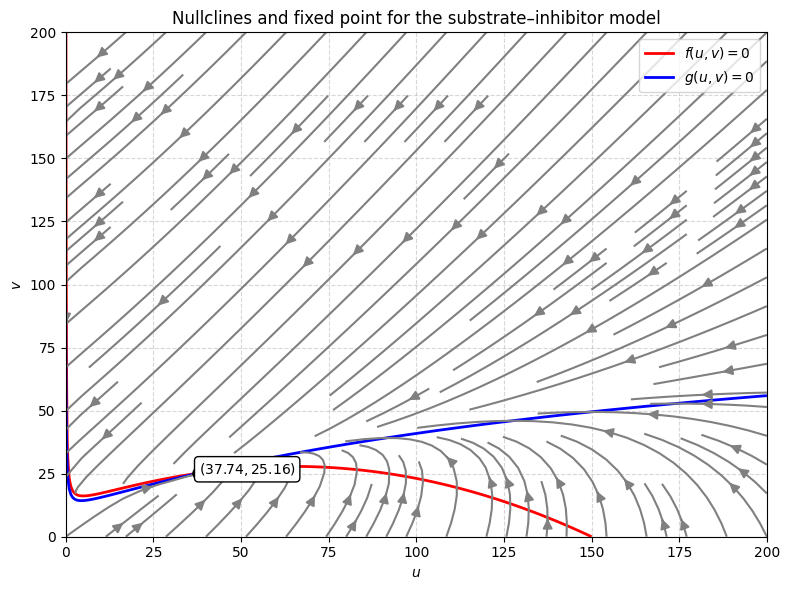

In [6]:
def f_phase(u, v):
    return substrate_f(u, v, a, rho, K)


def g_phase(u, v):
    return substrate_g(u, v, b, alpha, rho, K)


plot_phase_plane(
    f=f_phase,
    g=g_phase,
    u0=u0,
    v0=v0,
    u_range=(0.01, max(u0 + 40, 200)),
    v_range=(0.01, max(v0 + 40, 200)),
    title="Nullclines and fixed point for the substrate–inhibitor model"
)

## 4. Jacobian and local stability

We now linearise the reaction terms around the homogeneous steady state. The Jacobian is

$$
J =
\begin{pmatrix}
f_u & f_v \\
g_u & g_v
\end{pmatrix}.
$$

Evaluating this matrix at $(u_0,v_0)$ allows us to check whether the steady state is stable in the absence of diffusion. Stability requires

$$
\operatorname{tr}(J) < 0, \qquad \det(J) > 0.
$$

In [7]:
fu, fv, gu, gv = substrate_inhibitor_derivatives(a, b, alpha, rho, K, u0, v0)

J = np.array([
    [fu, fv],
    [gu, gv]
])

trJ, detJ = trace_det(fu, fv, gu, gv)
eigvals = np.linalg.eigvals(J)

print("Jacobian at steady state:")
print(J)

print("\nTrace and determinant:")
print(f"tr(J)  = {trJ:.4f}")
print(f"det(J) = {detJ:.4f}")

print("\nEigenvalues:")
for i, eig in enumerate(eigvals, start=1):
    print(f"lambda_{i} = {eig:.4f}")

print("\nStable without diffusion?")
print(trJ < 0 and detJ > 0)

Jacobian at steady state:
[[ 0.89958351 -4.46212685]
 [ 1.89958351 -5.96212685]]

Trace and determinant:
tr(J)  = -5.0625
det(J) = 3.1128

Eigenvalues:
lambda_1 = -0.7162
lambda_2 = -4.3464

Stable without diffusion?
True


## 5. Dispersion relation and unstable modes

To understand which spatial modes grow after diffusion is introduced, we study the dispersion relation. The function $h(k^2)$ determines whether perturbations with wavenumber $k$ can become unstable.

When $h(k^2)<0$, the dominant eigenvalue becomes positive for a band of spatial modes, indicating diffusion-driven instability.

As in the Schnakenberg case, we compare values of the diffusion ratio below, at, and above the critical threshold $d_c$.

Critical diffusion ratio: dc = 27.0152


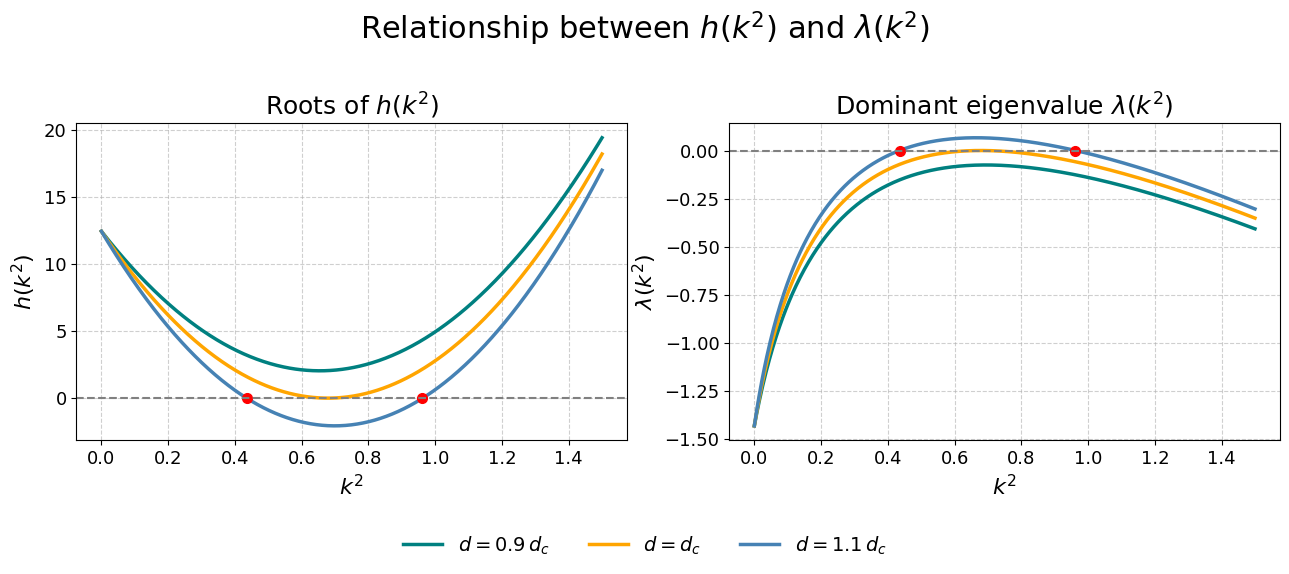

In [8]:
fu, fv, gu, gv = substrate_inhibitor_derivatives(a, b, alpha, rho, K, u0, v0)
dc = critical_diffusion_ratio(fu, fv, gu, gv)

print(f"Critical diffusion ratio: dc = {dc:.4f}")

d_vals = [0.9 * dc, dc, 1.1 * dc]
labels = [r"$d = 0.9\,d_c$", r"$d = d_c$", r"$d = 1.1\,d_c$"]
colors = ["teal", "orange", "steelblue"]

k2_vals = np.linspace(0, 1.5, 600)

plot_turing_relation(
    k2_vals=k2_vals,
    fu=fu,
    fv=fv,
    gu=gu,
    gv=gv,
    gamma=gamma,
    d_vals=d_vals,
    labels=labels,
    colors=colors,
)

## 6. Conclusion

For the substrate–inhibitor system, the homogeneous steady state must be computed numerically due to the nonlinear inhibition term. Despite this added complexity, we find that there exist parameter regimes in which the steady state is stable without diffusion but becomes unstable once diffusion is introduced.

The parameter-space analysis shows that Turing instability occurs over a more restricted and sensitive region compared to the Schnakenberg model. This reflects the stronger nonlinear coupling and saturation effects present in the system.

Overall, the substrate–inhibitor model exhibits diffusion-driven instability, but with greater dependence on parameter choice and numerical evaluation of the steady state.